# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List, Callable, Optional

import matplotlib.pyplot as plt
import numpy as np


## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        return ((X @ w - y) ** 2).mean()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        return 2 / X.shape[0] * (X.T @ (X @ w - y))

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """

    trace = [w_init]

    for i in range(n_iterations):
        trace.append(trace[i] - lr * loss.calc_grad(X, y, trace[i]))

    return trace[1:]



Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.26258214351938
0.8670644395649493


In [8]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    #Добавил, чтоб в дополнительном задании использовать функцию
    X = X.copy()
    X = X[:, 0:2]

    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    """
    plt.xlim(np.min([w_list[:, 0].min() - 0.1, -1]), np.max([w_list[:, 0].max() + 0.1, 1]))
    plt.ylim(np.min([w_list[:, 1].min() - 0.1, -1]), np.max([w_list[:, 1].max() + 0.1, 1]))
    """
    #Изменил из-за того, что у меня график ломался. 
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    

    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])
    
    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

Длина шага = 0.0001


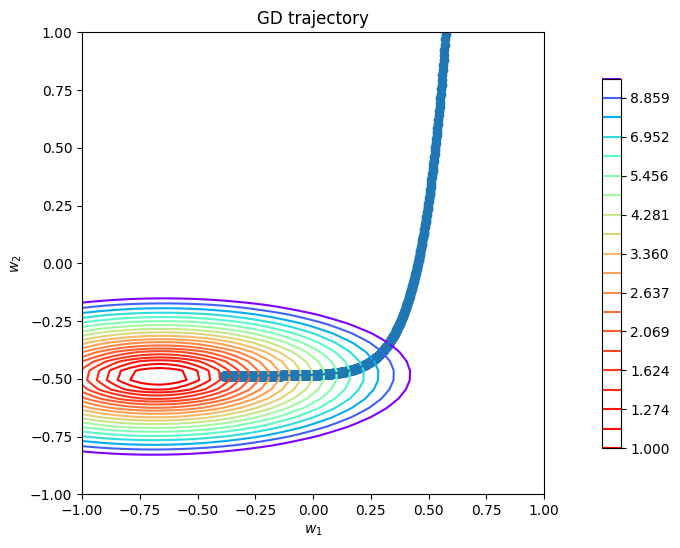

Длина шага = 0.00032


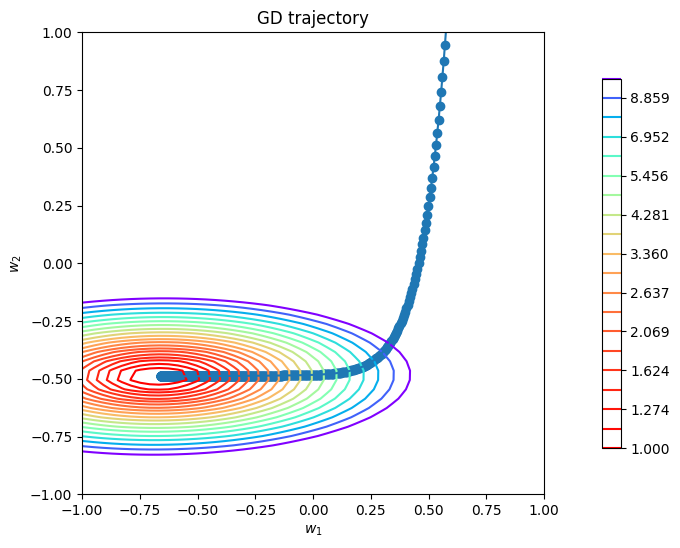

Длина шага = 0.001


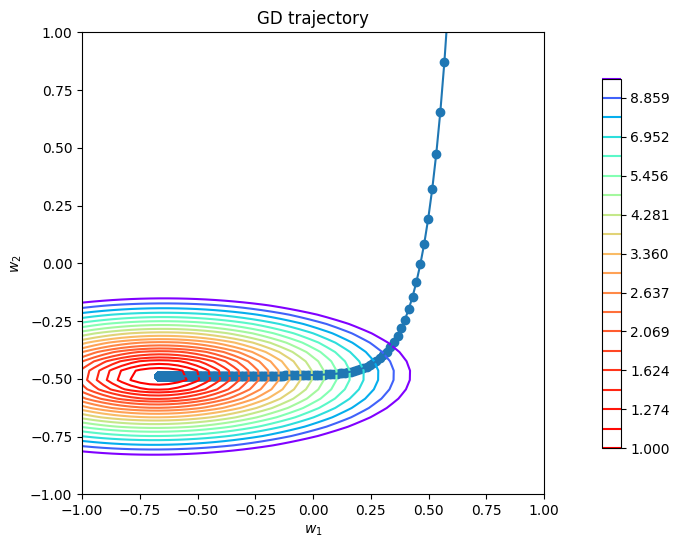

Длина шага = 0.00316


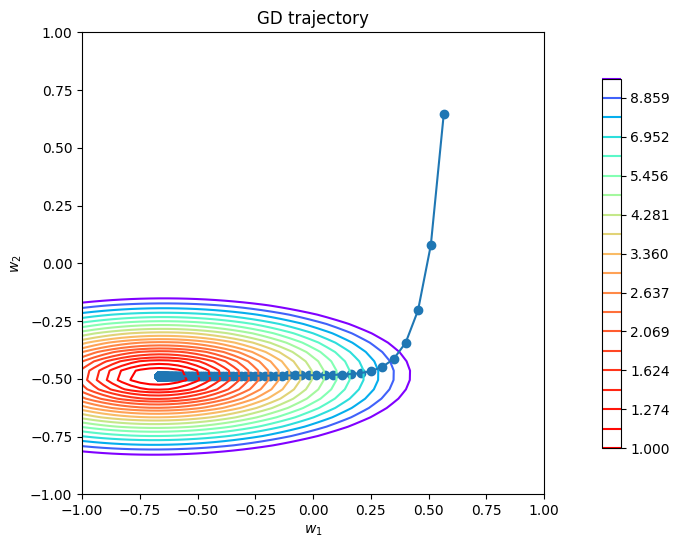

Длина шага = 0.01


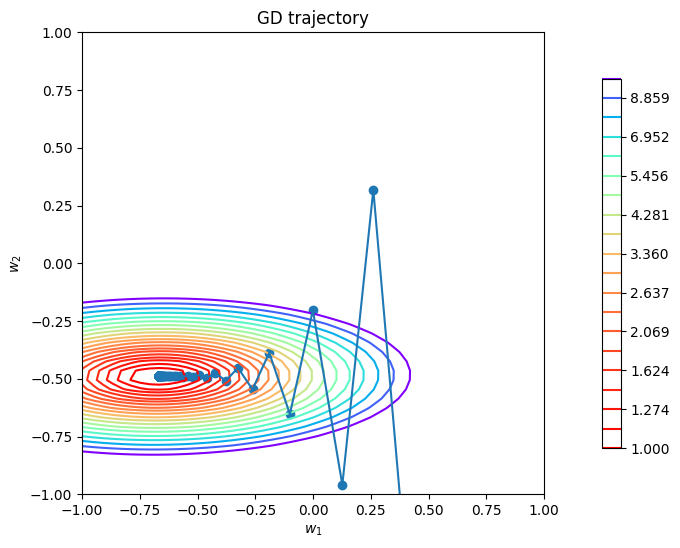

Длина шага = 0.03162


C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1261494808.py:20: RuntimeWarning: overflow encountered in matmul
  return 2 / X.shape[0] * (X.T @ (X @ w - y))
C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1261494808.py:20: RuntimeWarning: invalid value encountered in matmul
  return 2 / X.shape[0] * (X.T @ (X @ w - y))
C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1931893346.py:23: RuntimeWarning: invalid value encountered in subtract
  trace.append(trace[i] - lr * loss.calc_grad(X, y, trace[i]))


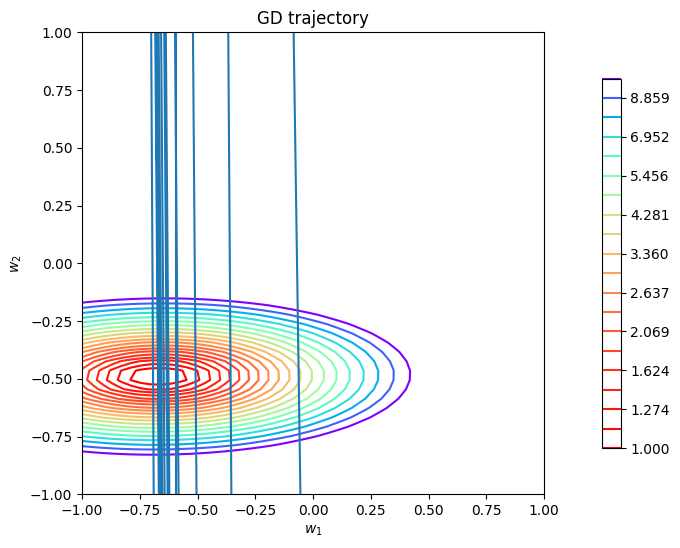

Длина шага = 0.1


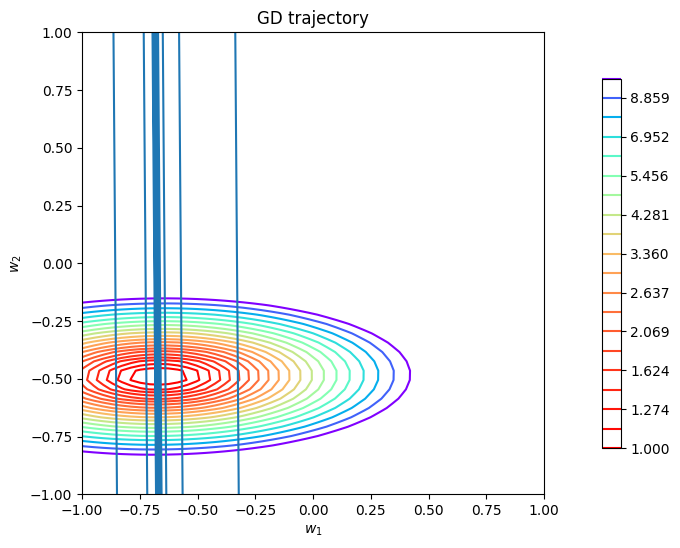

In [9]:
for lr_i in np.logspace(-4, -1, 7): # Это от 0.0001 до 0.1
    print(f"Длина шага = {np.round(lr_i, 5)}")
    plot_gd(gradient_descent(w_init, X, y, loss, lr_i, 1000), X, y, loss)

Вывод:  
Длина шага - гиперпараметр требующий подбора. При малых значениях нахождение минимума потребует большого количества итераций, а при больших - минимум будет перепрыгиваться.

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    
    trace = [w_init]

    for i in range(n_iterations):
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        trace.append(trace[i] - lr * loss.calc_grad(X[batch_indices, :], y[batch_indices], trace[i]))

    return trace[1:]

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

batch_size: 75.0; lr: 0.001


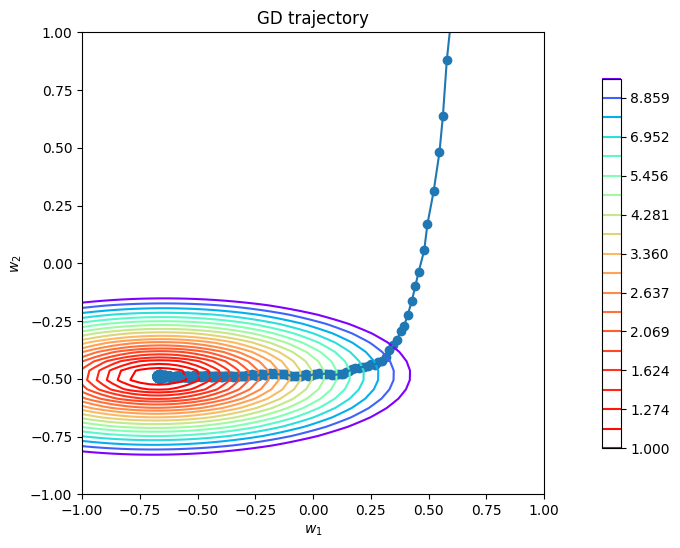

batch_size: 75.0; lr: 0.0031622776601683794


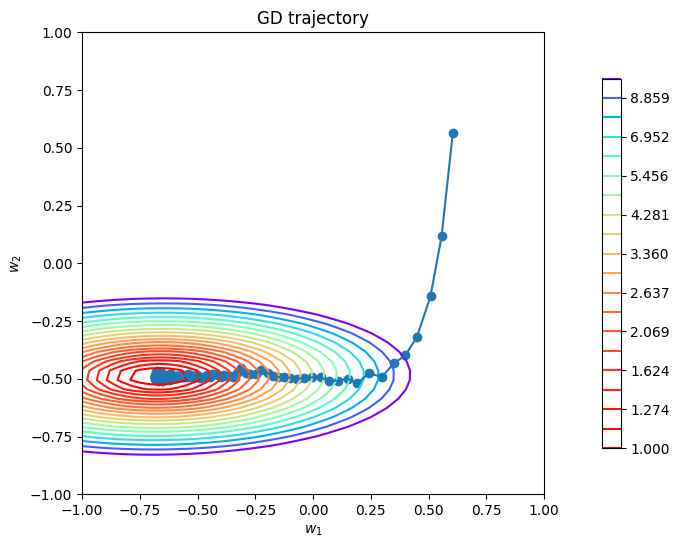

batch_size: 75.0; lr: 0.01


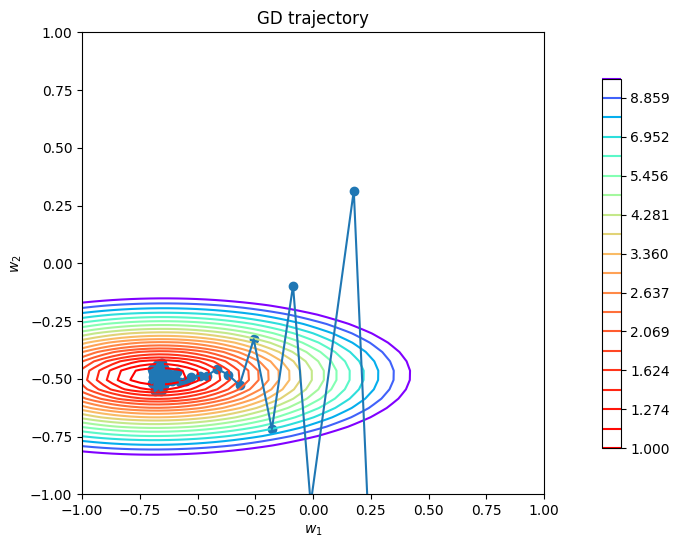

batch_size: 75.0; lr: 0.03162277660168379


C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1261494808.py:20: RuntimeWarning: overflow encountered in matmul
  return 2 / X.shape[0] * (X.T @ (X @ w - y))
C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1261494808.py:20: RuntimeWarning: invalid value encountered in matmul
  return 2 / X.shape[0] * (X.T @ (X @ w - y))
C:\Users\ilaes\AppData\Local\Temp\ipykernel_7328\1929438005.py:26: RuntimeWarning: invalid value encountered in subtract
  trace.append(trace[i] - lr * loss.calc_grad(X[batch_indices, :], y[batch_indices], trace[i]))


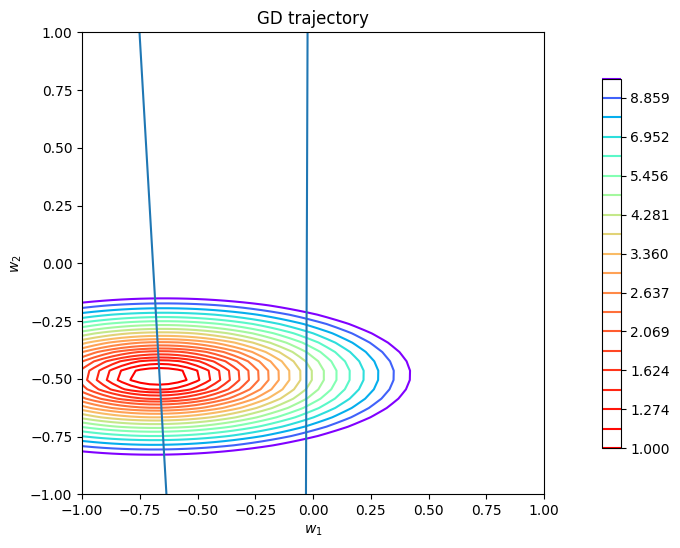

batch_size: 150.0; lr: 0.001


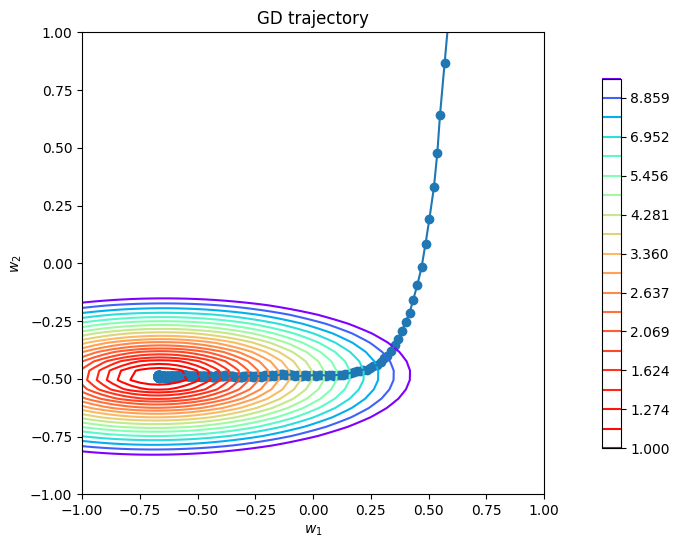

batch_size: 150.0; lr: 0.0031622776601683794


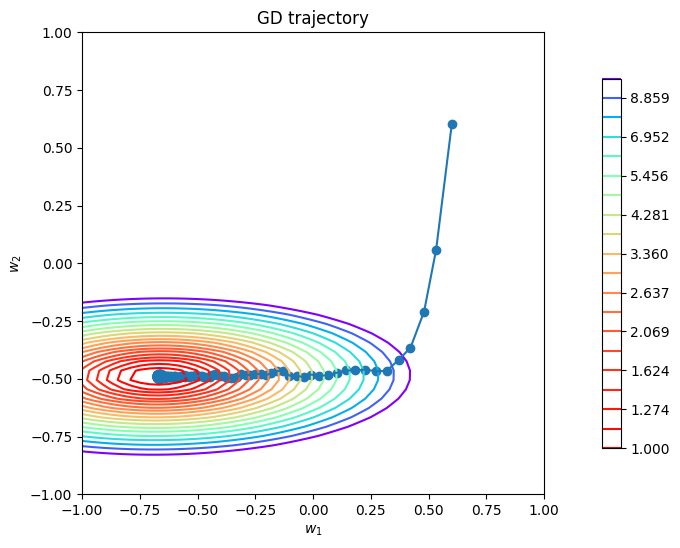

batch_size: 150.0; lr: 0.01


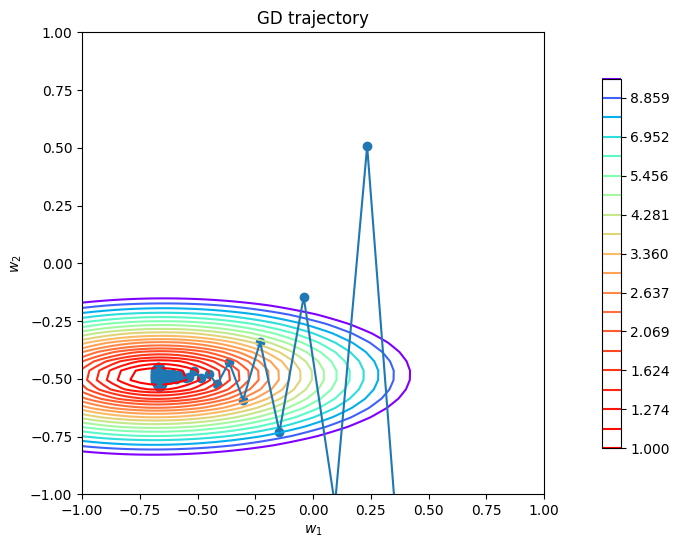

batch_size: 150.0; lr: 0.03162277660168379


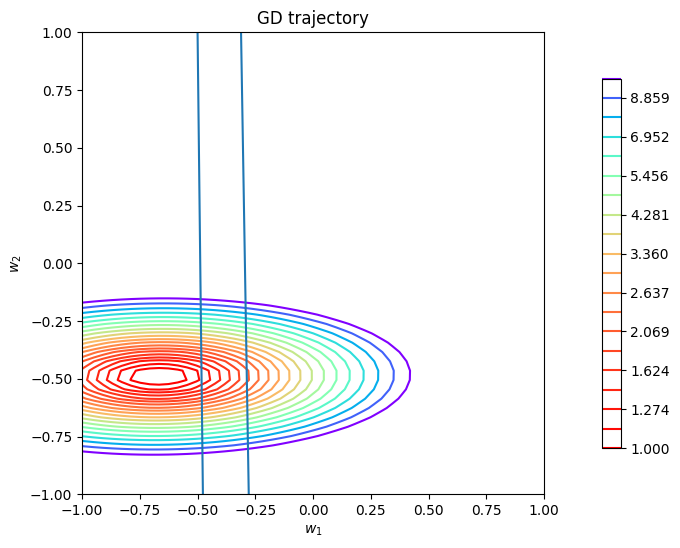

batch_size: 225.0; lr: 0.001


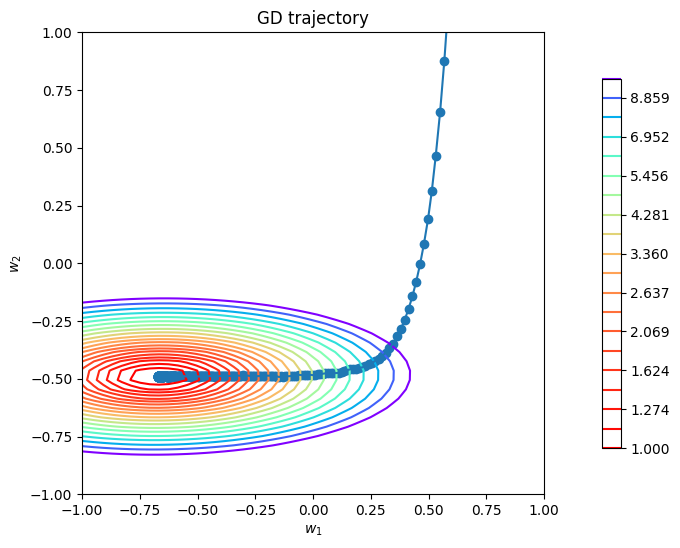

batch_size: 225.0; lr: 0.0031622776601683794


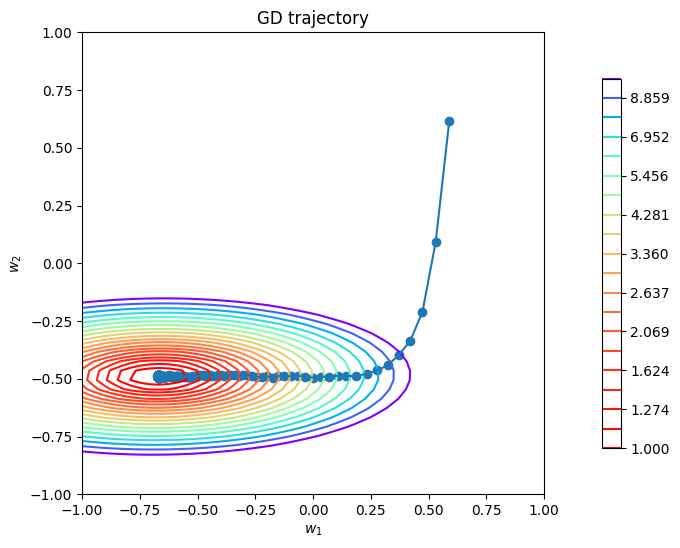

batch_size: 225.0; lr: 0.01


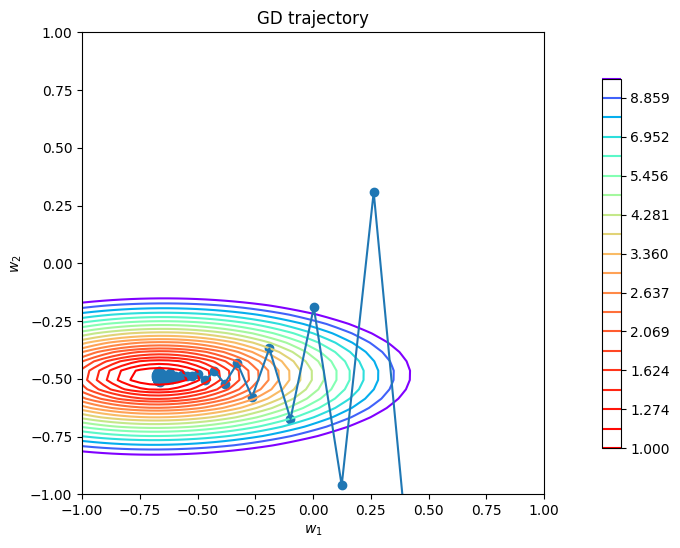

batch_size: 225.0; lr: 0.03162277660168379


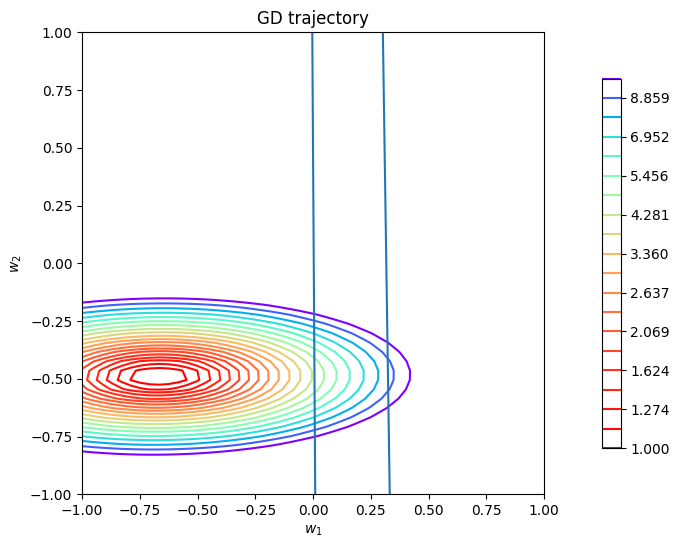

batch_size: 300.0; lr: 0.001


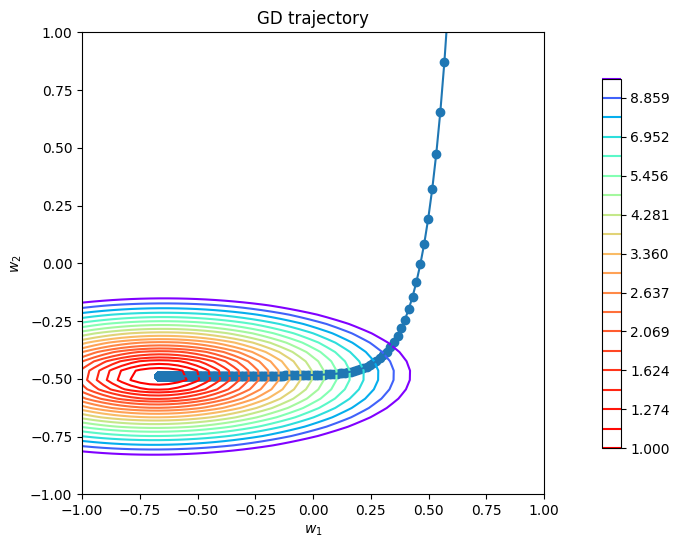

batch_size: 300.0; lr: 0.0031622776601683794


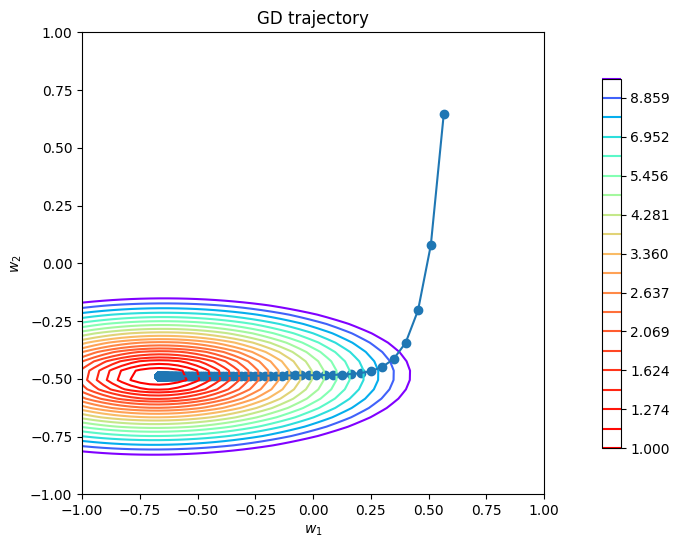

batch_size: 300.0; lr: 0.01


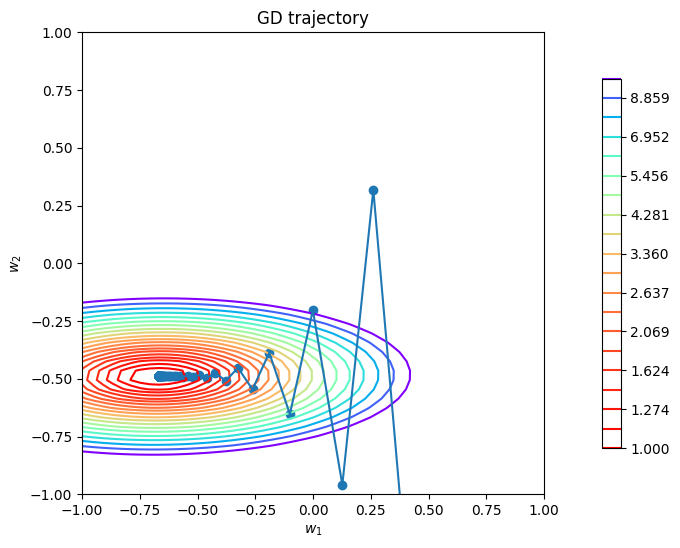

batch_size: 300.0; lr: 0.03162277660168379


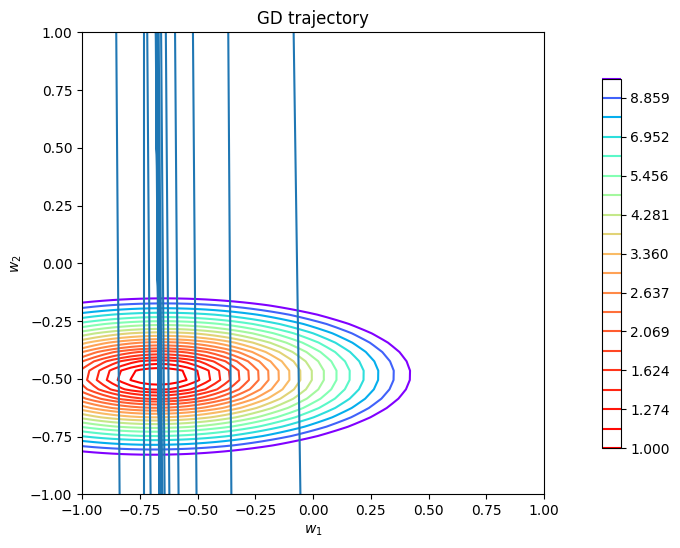

In [11]:
for batch_size_i in np.linspace(75, 300, 4):
    for lr_i in np.logspace(-3, -1.5, 4):
        print(f"batch_size: {batch_size_i}; lr: {lr_i}")
        plot_gd(stochastic_gradient_descent(w_init, X, y, loss, lr_i, int(batch_size_i)), X, y, loss)

Выводы:  
При уменьшении доли batch`а вектор шага смещается от реального направления антиградиента. При больлших batch_size стахостический градиентный спуск будет вести себя почти как обычный. Размер шага влияет на стахостический метод также, как и на обычный. При большом размере шага даже незначительные отклонения от реального антиградиента приводят к сильным промахам.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [12]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    trace = [w_init]

    for i in range(n_iterations):
        step_len = lr * ((1 / (1 + i)) ** p)
        batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
        trace.append(trace[i] - step_len * loss.calc_grad(X[batch_indices, :], y[batch_indices], trace[i]))

    return trace[1:]

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

p: 0.1


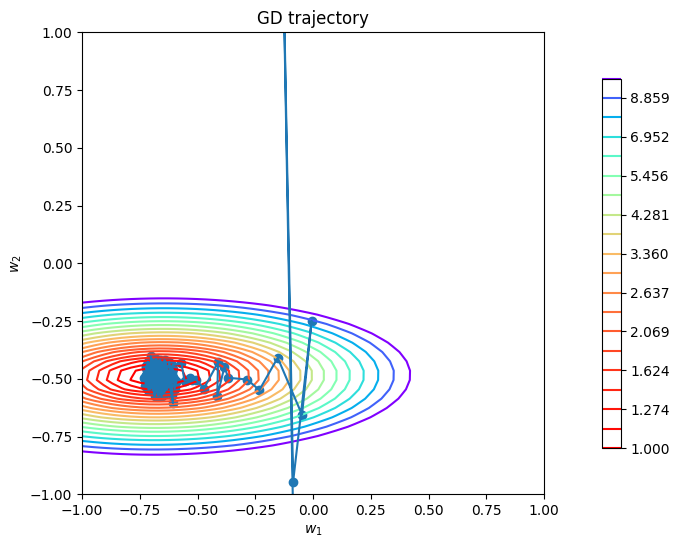

p: 0.325


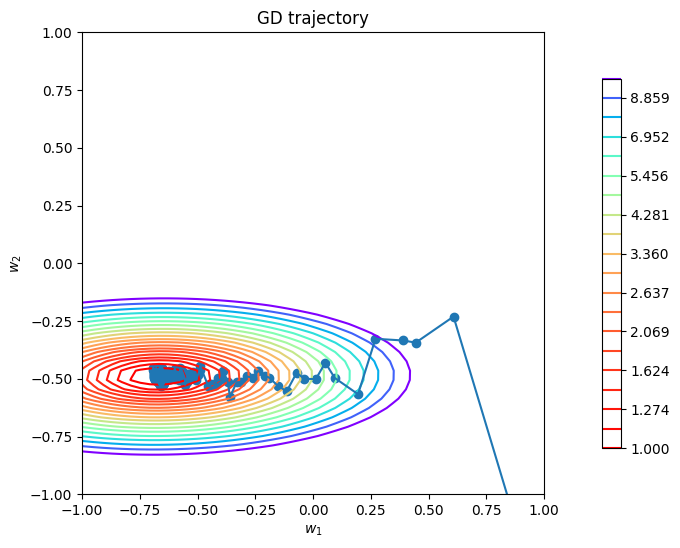

p: 0.55


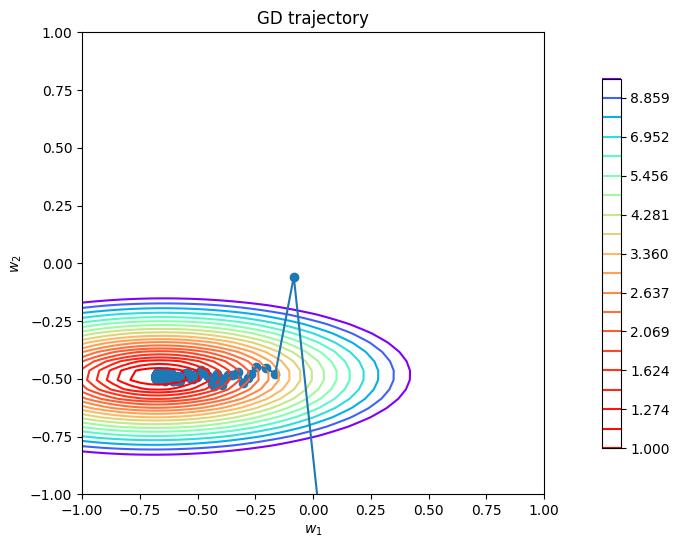

p: 0.775


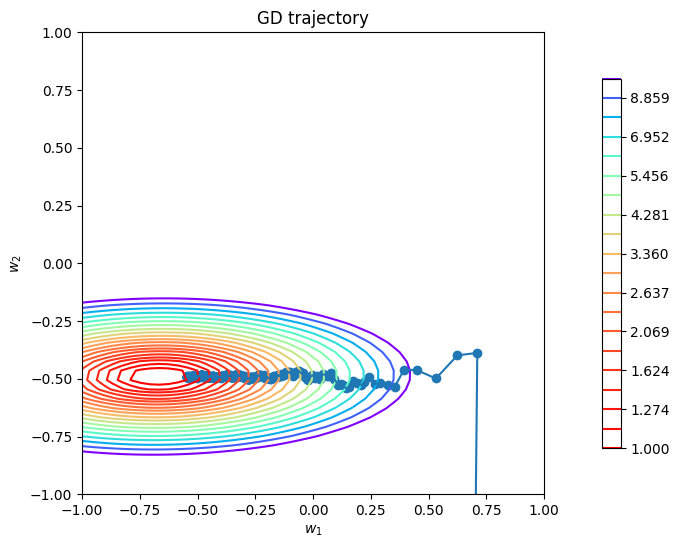

p: 1.0


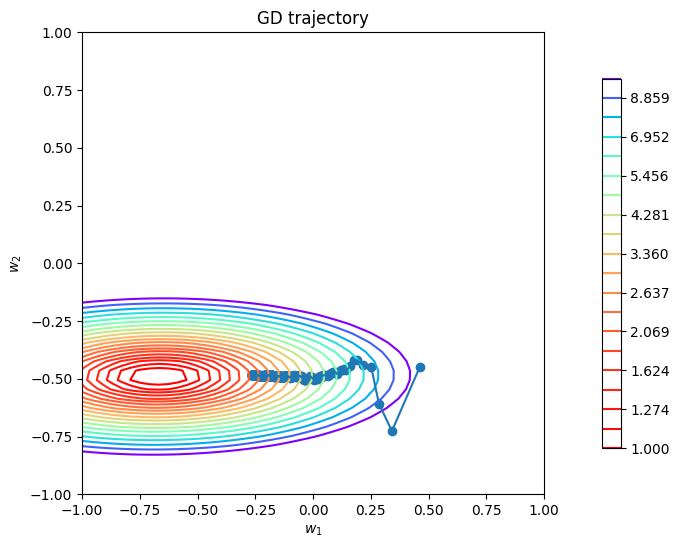

In [13]:
for p in np.linspace(0.1, 1, 5):
    print(f"p: {p}")
    plot_gd(stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, p), X, y, loss)

Выводы:  
При малых p веса сходятся слишком долго. При больших - веса слишком долго достигают минимума или же вовсе не достигают его.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

Text(0, 0.5, 'MSE')

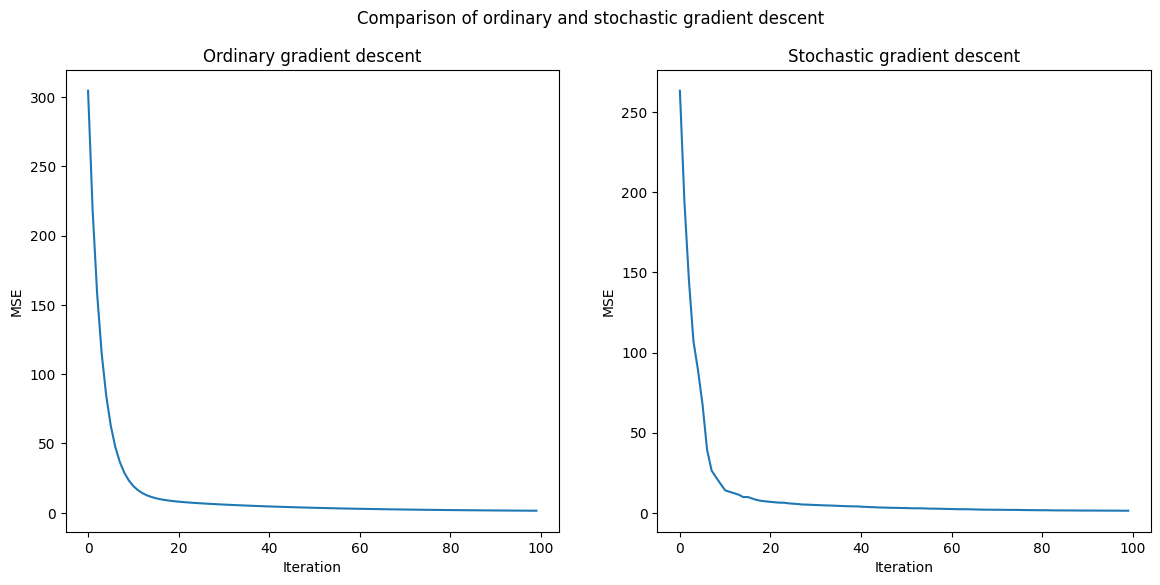

In [14]:
ogd_w = w_init
sgd_w = w_init

ogd_loss = []
sgd_loss = []

lr = 0.001
p = 0.3

ml = MSELoss()

iterations_number = 100

for i in range(iterations_number):
    ogd_w = ogd_w - lr * ml.calc_grad(X, y, ogd_w)
    ogd_loss.append(ml.calc_loss(X, y, ogd_w))

    batch_indices = np.random.choice(X.shape[0], size=10, replace=False)
    step_len = lr * ((1 / (1 + i)) ** p)
    sgd_w = sgd_w - lr * ml.calc_grad(X[batch_indices, :], y[batch_indices], sgd_w)
    sgd_loss.append(ml.calc_loss(X, y, sgd_w))


fig, axes = plt.subplots(1, 2, figsize = (14, 6))

fig.suptitle("Comparison of ordinary and stochastic gradient descent")

axes[0].set_title("Ordinary gradient descent")
axes[0].plot(list(range(iterations_number)), ogd_loss)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")

axes[1].set_title("Stochastic gradient descent")
axes[1].plot(list(range(iterations_number)), sgd_loss)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE")




Выводы:  
Если судить только по графику sgd уменьшает ошибку медленее, чем обычный gd. Но его главный плюс в том, что в нем не нужно на каждой итерации считать градиент для всех объектов, а лишь для некоторой части.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [15]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w_init = np.random.randn(X.shape[1]) * 0.05
        self.w = gradient_descent(w_init, X, y, self.loss, self.lr, 10000)[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [16]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [17]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [18]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [19]:
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

print(f"Пропусков в Целевой переменной: {y.isna().sum()}")
print(f"Пропусков в параметрам: {np.sum(X_raw.isna())}")

X_raw_train, X_raw_test, y_train, y_test = train_test_split(X_raw, y, train_size=0.7, random_state=42)

imputer = SimpleImputer(strategy="mean")
scaler = MinMaxScaler()

cat_features_mask = (X_raw.dtypes == "str").values

X_train_real = pd.DataFrame(
    scaler.fit_transform(imputer.fit_transform(X_raw_train[X_raw_train.columns[~cat_features_mask]])),
    columns=X_raw_train.columns[~cat_features_mask],
    index=X_raw_train[X_raw_train.columns[~cat_features_mask]].index
)

X_test_real = pd.DataFrame(
    scaler.transform(imputer.transform(X_raw_test[X_raw_test.columns[~cat_features_mask]])),
    columns=X_raw_test.columns[~cat_features_mask],
    index=X_raw_test[X_raw_test.columns[~cat_features_mask]].index
)
X_train_cat = X_raw_train[X_raw_train.columns[cat_features_mask]].fillna("")
X_test_cat = X_raw_test[X_raw_test.columns[cat_features_mask]].fillna("")

X_train = pd.concat([X_train_real, X_train_cat], axis=1)
X_test = pd.concat([X_test_real, X_test_cat], axis=1)

X_train = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, drop_first=True, dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_test.head()


Пропусков в Целевой переменной: 0
Пропусков в параметрам: 51


,1,2,10,11,12,13,14,17,19,20,...,16_three,16_twelve,16_two,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
95,0.8,0.539267,0.206154,0.317910,0.299145,0.458333,0.201707,0.135849,0.484127,0.580952,...,0,0,0,1,0,0,0,0,0,0
15,0.4,0.295077,0.464615,0.786567,0.649573,0.491667,0.733902,0.558491,0.857143,0.628571,...,0,0,0,0,0,0,0,1,0,0
30,0.8,0.376963,-0.055385,0.052239,0.307692,0.250000,0.128394,0.116981,0.293651,0.638095,...,0,0,0,0,0,0,0,0,0,0
158,0.4,0.136126,0.224615,0.376119,0.350427,0.416667,0.252909,0.139623,0.515873,0.457143,...,0,0,0,1,0,0,0,0,0,0
128,1.0,0.445026,0.329231,0.679104,0.529915,0.691667,0.453840,0.226415,0.793651,0.476190,...,0,0,0,0,0,0,0,1,0,0


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [20]:
linear_regression = LinearRegression(MSELoss(), 0.007)

linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"MSE на обучающей выборке:{mean_squared_error(y_train, linear_regression.predict(X_train))}")
print(f"MSE на тестовой выборке:{mean_squared_error(y_test, linear_regression.predict(X_test))} \n")

print(f"R2 на обучающей выборке:{r2_score(y_train, linear_regression.predict(X_train))}")
print(f"R2 на тестовой выборке:{r2_score(y_test, linear_regression.predict(X_test))}")

MSE на обучающей выборке:2524771.9151604543
MSE на тестовой выборке:7847756.88627447 

R2 на обучающей выборке:0.9475977848847565
R2 на тестовой выборке:0.9172104694390132


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [22]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        w_temp = w
        w_temp[-1] = 0
        return ((X @ w - y) ** 2).mean() + self.coef * (w_temp ** 2).sum()

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        w_temp = w
        w_temp[-1] = 0
        return 2 / X.shape[0] * (X.T @ (X @ w - y)) + 2 * self.coef * w_temp

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [23]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [24]:
best_coef= 0
min_error = (float("+inf"), float("+inf"))
best_model = LinearRegression(MSELoss())

for coef in np.logspace(-15, 1):
    msel2 = MSEL2Loss(coef)
    linear_regression = LinearRegression(msel2, 0.01)
    linear_regression.fit(X_train, y_train)

    if (msel2.calc_loss(np.hstack([X_test, np.ones((X_test.shape[0], 1))]), y_test, linear_regression.w) < min_error[1]):
        best_coef = coef
        min_error = (msel2.calc_loss(np.hstack([X_train, np.ones((X_train.shape[0], 1))]), y_train, linear_regression.w), 
                     msel2.calc_loss(np.hstack([X_test, np.ones((X_test.shape[0], 1))]), y_test, linear_regression.w))
        best_model = linear_regression

print(f"Наименьшая MSEL2 достигается при коэффициенте {best_coef}")
print(f"MSEL2 на обучающей выборке:{ min_error[0]}")
print(f"MSEL2 на тестовой выборке:{min_error[1]} \n")

print(f"R2 на обучающей выборке:{r2_score(y_train, best_model.predict(X_train))}")
print(f"R2 на тестовой выборке:{r2_score(y_test, best_model.predict(X_test))}")


Наименьшая MSEL2 достигается при коэффициенте 1.9306977288832457e-13
MSEL2 на обучающей выборке:2309914.3478931184
MSEL2 на тестовой выборке:7248346.261932593 

R2 на обучающей выборке:0.9520572025438727
R2 на тестовой выборке:0.9235339227428017


Выводы:  
Похоже модель без регуляризации не была переобучена, т.к. оптимальный коэффициент регуляризации получился около 0. Возможно подразумевалось, что данные нужно подготовить как-то иначе, что привело бы к ошибке, которая решалась бы с помощью регуляризации. Но я  не понял как это можно было бы сделать.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [25]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        errors = X @ w - y
        errors_less_eps = errors[np.abs(errors) < self.eps]
        errors_greater_eps = errors[np.abs(errors) >= self.eps]

        less_error = (errors_less_eps ** 2 / 2).sum()
        greater_error = (self.eps * (np.abs(errors_greater_eps) - self.eps / 2)).sum()

        return (less_error + greater_error) / X.shape[0]

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        errors = X @ w - y

        greater_mask = np.abs(errors) >= self.eps
        errors[greater_mask] = self.eps * np.sign(errors[greater_mask])

        return X.T @ errors / X.shape[0]

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [26]:
eps = 1.48 * np.median(np.abs(y_train - np.median(y_train)))

hl =HuberLoss(eps)
linear_regression = LinearRegression(hl, 0.01)
linear_regression.fit(X_train, y_train)

print(f"Eps: {eps}")
print(f"HL на обучающей выборке:{hl.calc_loss(np.hstack([X_train, np.ones((X_train.shape[0], 1))]), y_train, linear_regression.w)}")
print(f"HL на тестовой выборке:{hl.calc_loss(np.hstack([X_test, np.ones((X_test.shape[0], 1))]), y_test, linear_regression.w)} \n")

print(f"R2 на обучающей выборке:{r2_score(y_train, linear_regression.predict(X_train))}")
print(f"R2 на тестовой выборке:{r2_score(y_test, linear_regression.predict(X_test))}")

Eps: 5065.3
HL на обучающей выборке:1503029.4877760916
HL на тестовой выборке:3569724.000125167 

R2 на обучающей выборке:0.9364712112009108
R2 на тестовой выборке:0.9069418879401818


Выводы:  
HuberLoss даёт меньшую точность чем MSEL2, но разница незначительная.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [27]:
# -- YOUR MEME HERE -- ╰( ͡° ͜ʖ ͡° )つ▬▬ι═══════  bzzzzzzzzzz

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [28]:
def simulated_annealing(
    func: Callable[[np.ndarray], float],
    w_init: np.ndarray,
    bounds: Optional[np.ndarray] = None,
    initial_temp: float = 100.0,
    cooling_rate: float = 0.95,
    n_iterations: int = 100000,
    min_temp: float = 1e-3,
    delta_abs: float = 1.0,
    delta_rel: float = 0.5
) -> List[np.ndarray]:
    
    if bounds is None:
        bounds = []
        for wi in w_init:
            D = max(delta_abs, delta_rel * abs(wi))
            bounds.append((wi - D, wi + D))
        bounds = np.array(bounds)
    
    trace = [w_init.copy()]
    temperature = initial_temp
    current = w_init.copy()
    current_energy = func(current)
    
    for _ in range(n_iterations):
        if temperature < min_temp:
            break
        
        neighbor = current + np.random.standard_t(3, size=current.shape)
        
        for i in range(len(bounds)):
            neighbor[i] = np.clip(neighbor[i], bounds[i][0], bounds[i][1])
        
        neighbor_energy = func(neighbor)
        delta = neighbor_energy - current_energy
        
        if delta < 0 or np.random.random() < np.exp(-delta / temperature):
            current = neighbor
            current_energy = neighbor_energy
            trace.append(current.copy())
        
        temperature *= cooling_rate
    
    return trace

Значения MSE
MSE градиентного спуска на train: 5100576.919034072
MSE градиентного спуска на test: 14289366.142524865 

MSE имитации отжига на train: 144862234.34714833
MSE имитации отжига на test: 224924513.4008306


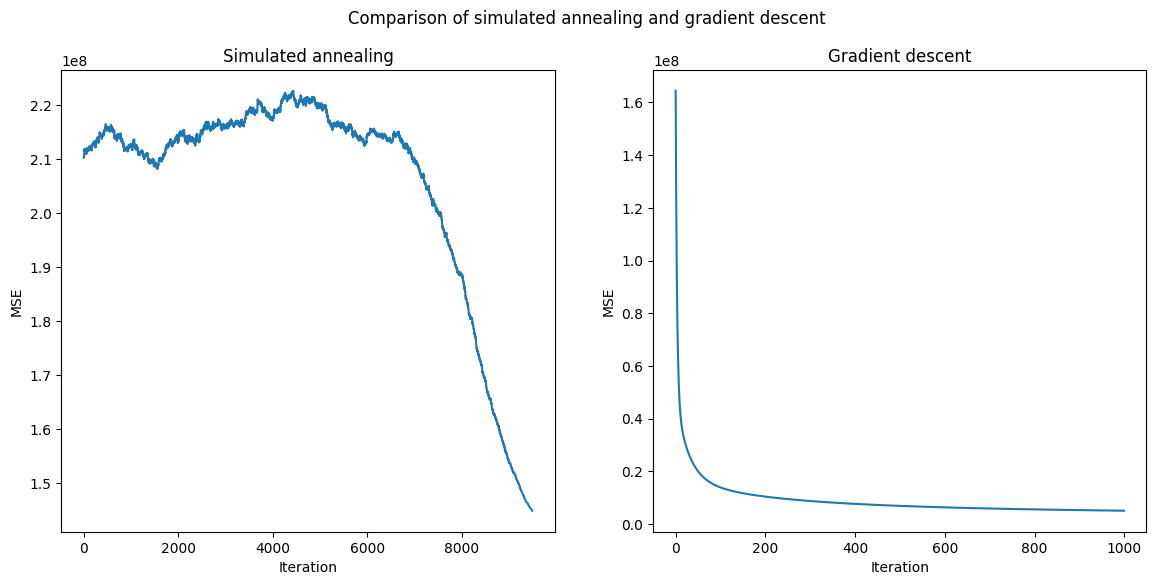

In [29]:
X_train_with_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test_with_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

w_init = np.random.randn(X_train_with_bias.shape[1]) * 0.05

gd_trace = gradient_descent(w_init, X_train_with_bias, y_train, MSELoss(), 0.01, 1000)
sa_trace = simulated_annealing(lambda w: MSELoss().calc_loss(X_train_with_bias, y_train, w), w_init, initial_temp=500000000, cooling_rate=0.999, n_iterations=100000, delta_abs=200)

gd_errors = [mean_squared_error(y_train, X_train_with_bias @ w) for w in gd_trace]
sa_errors = [mean_squared_error(y_train, X_train_with_bias @ w) for w in sa_trace]


fig, axes = plt.subplots(1, 2, figsize = (14, 6))

fig.suptitle("Comparison of simulated annealing and gradient descent")

axes[0].set_title("Simulated annealing")
axes[0].plot(sa_errors)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")

axes[1].set_title("Gradient descent")
axes[1].plot(list(range(1000)), gd_errors)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("MSE")

print("Значения MSE")
print(f"MSE градиентного спуска на train: {mean_squared_error(y_train, X_train_with_bias @ gd_trace[-1])}")
print(f"MSE градиентного спуска на test: {mean_squared_error(y_test, X_test_with_bias @ gd_trace[-1])} \n")

print(f"MSE имитации отжига на train: {mean_squared_error(y_train, X_train_with_bias @ sa_trace[-1])}")
print(f"MSE имитации отжига на test: {mean_squared_error(y_test, X_test_with_bias @ sa_trace[-1])}")


Я попробовал поподбирать гиперпараметры у sa, и удалось добиться вот таких результатов. Градиентный спуск достигает минимума лучше, чем имитация отжига. Но плюс имитации отжига в том, что он работает на сложных функциях, у которых может не быть производных.